In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os
from pathlib import Path

print("🚀 HelpDesk AI Environment Ready!")

🚀 HelpDesk AI Environment Ready!


In [8]:
DATA_DIR = Path("../data/raw")

for file in DATA_DIR.iterdir():
    print(file.name)

movie_characters_metadata.tsv
movie_conversations.tsv
movie_lines.tsv
movie_titles_metadata.tsv
raw_script_urls.tsv
README.txt


In [20]:
with open("../data/raw/movie_lines.tsv", "rb") as f:
    print(f.readline())

b'L1045\tu0\tm0\tBIANCA\tThey do not!\r\n'


In [21]:
import csv

with open("../data/raw/movie_lines.tsv", encoding="utf-8") as f:
    reader = csv.reader(f, delimiter="\t")

    for i, row in enumerate(reader):
        print(row)
        if i == 4:
            break

['L1045', 'u0', 'm0', 'BIANCA', 'They do not!']
['L1044', 'u2', 'm0', 'CAMERON', 'They do to!']
['L985', 'u0', 'm0', 'BIANCA', 'I hope so.']
['L984', 'u2', 'm0', 'CAMERON', 'She okay?']
['L925', 'u0', 'm0', 'BIANCA', "Let's go."]


In [23]:
movie_lines = {}

with open("../data/raw/movie_lines.tsv", encoding="utf-8") as f:

    for line in f:

        parts = line.strip().split("\t")

        if len(parts) < 5:
            continue

        line_id = parts[0]

        character = parts[3]

        dialogue = "\t".join(parts[4:])

        movie_lines[line_id] = {
            "character": character,
            "text": dialogue
        }

print("Total movie lines:", len(movie_lines))

Total movie lines: 304446


In [24]:
list(movie_lines.items())[:5]

[('L1045', {'character': 'BIANCA', 'text': 'They do not!'}),
 ('L1044', {'character': 'CAMERON', 'text': 'They do to!'}),
 ('L985', {'character': 'BIANCA', 'text': 'I hope so.'}),
 ('L984', {'character': 'CAMERON', 'text': 'She okay?'}),
 ('L925', {'character': 'BIANCA', 'text': "Let's go."})]

In [27]:
conversations = []

with open("../data/raw/movie_conversations.tsv", encoding="utf-8") as f:

    for line in f:

        parts = line.strip().split("\t")

        if len(parts) < 4:
            continue

        conversations.append(parts)

print("Total conversations:", len(conversations))

Total conversations: 83097


In [28]:
conversations[:5]

[['u0', 'u2', 'm0', "['L194' 'L195' 'L196' 'L197']"],
 ['u0', 'u2', 'm0', "['L198' 'L199']"],
 ['u0', 'u2', 'm0', "['L200' 'L201' 'L202' 'L203']"],
 ['u0', 'u2', 'm0', "['L204' 'L205' 'L206']"],
 ['u0', 'u2', 'm0', "['L207' 'L208']"]]

In [29]:
import re

question_answer_pairs = []

for conv in conversations:

    line_ids = re.findall(r"L\d+", conv[3])

    for i in range(len(line_ids)-1):

        q_id = line_ids[i]
        a_id = line_ids[i+1]

        if q_id in movie_lines and a_id in movie_lines:

            question_answer_pairs.append(
                (
                    movie_lines[q_id]["text"],
                    movie_lines[a_id]["text"]
                )
            )

print("Total QA Pairs:", len(question_answer_pairs))

Total QA Pairs: 215432


In [30]:
question_answer_pairs[:10]

[('Can we make this quick?  Roxanne Korrine and Andrew Barrett are having an incredibly horrendous public break- up on the quad.  Again.',
  "Well I thought we'd start with pronunciation if that's okay with you."),
 ("Well I thought we'd start with pronunciation if that's okay with you.",
  'Not the hacking and gagging and spitting part.  Please.'),
 ('Not the hacking and gagging and spitting part.  Please.',
  "Okay... then how 'bout we try out some French cuisine.  Saturday?  Night?"),
 ("You're asking me out.  That's so cute. What's your name again?",
  'Forget it.'),
 ("No no it's my fault -- we didn't have a proper introduction ---",
  'Cameron.'),
 ('Cameron.',
  "The thing is Cameron -- I'm at the mercy of a particularly hideous breed of loser.  My sister.  I can't date until she does."),
 ("The thing is Cameron -- I'm at the mercy of a particularly hideous breed of loser.  My sister.  I can't date until she does.",
  'Seems like she could get a date easy enough...'),
 ('Why?',


In [32]:
import re

def clean_text(text):

    text = text.lower()

    text = re.sub(r"i'm", "i am", text)
    text = re.sub(r"he's", "he is", text)
    text = re.sub(r"she's", "she is", text)
    text = re.sub(r"it's", "it is", text)
    text = re.sub(r"that's", "that is", text)
    text = re.sub(r"what's", "what is", text)
    text = re.sub(r"where's", "where is", text)
    text = re.sub(r"\'ll", " will", text)
    text = re.sub(r"\'ve", " have", text)
    text = re.sub(r"\'re", " are", text)
    text = re.sub(r"\'d", " would", text)
    text = re.sub(r"won't", "will not", text)
    text = re.sub(r"can't", "cannot", text)
    text = re.sub(r"n't", " not", text)

    text = re.sub(r"[^a-zA-Z0-9?.!,]+", " ", text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [33]:
clean_questions = []
clean_answers = []

for q, a in question_answer_pairs:

    q = clean_text(q)
    a = clean_text(a)

    if len(q.split()) >= 2 and len(a.split()) >= 2:

        clean_questions.append(q)
        clean_answers.append(a)

print("Questions:", len(clean_questions))
print("Answers :", len(clean_answers))

Questions: 184801
Answers : 184801


In [34]:
for i in range(10):
    print("Q:", clean_questions[i])
    print("A:", clean_answers[i])
    print()

Q: can we make this quick? roxanne korrine and andrew barrett are having an incredibly horrendous public break up on the quad. again.
A: well i thought we would start with pronunciation if that is okay with you.

Q: well i thought we would start with pronunciation if that is okay with you.
A: not the hacking and gagging and spitting part. please.

Q: not the hacking and gagging and spitting part. please.
A: okay... then how bout we try out some french cuisine. saturday? night?

Q: you are asking me out. that is so cute. what is your name again?
A: forget it.

Q: the thing is cameron i am at the mercy of a particularly hideous breed of loser. my sister. i cannot date until she does.
A: seems like she could get a date easy enough...

Q: unsolved mystery. she used to be really popular when she started high school then it was just like she got sick of it or something.
A: that is a shame.

Q: gosh if only we could find kat a boyfriend...
A: let me see what i can do.

Q: c esc ma tete. this 

In [35]:
question_lengths = [len(q.split()) for q in clean_questions]
answer_lengths = [len(a.split()) for a in clean_answers]

print("Questions")
print("Min:", min(question_lengths))
print("Max:", max(question_lengths))
print("Average:", sum(question_lengths)/len(question_lengths))

print()

print("Answers")
print("Min:", min(answer_lengths))
print("Max:", max(answer_lengths))
print("Average:", sum(answer_lengths)/len(answer_lengths))

Questions
Min: 2
Max: 319
Average: 11.536090172672226

Answers
Min: 2
Max: 502
Average: 11.898555743745975


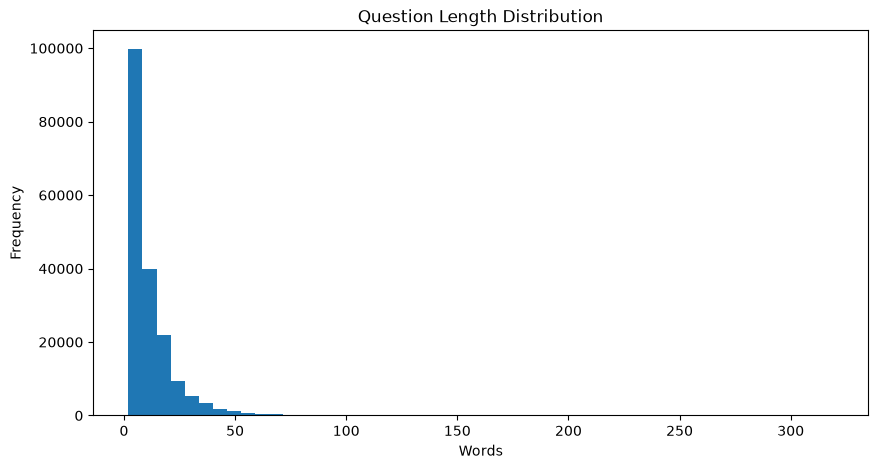

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(question_lengths, bins=50)
plt.title("Question Length Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()